# Point-Process JSCC — temporal codes over a jitter channel

```
source S  --encoder-->  X  --jitter-->  Y = X + Z  --decoder-->  S_hat
```

`Z_i ~ N(0, sigma_J^2)`, `N_X = N_S`, `R = Ts/Tc = 1`, `D = E[(1/N) sum_i (T_i - T_hat_i)^2]`.

Three systems compared everywhere, at identical rate and event count:

| system | X | S_hat |
| --- | --- | --- |
| `uncoded` | `S` | `Y` |
| `decoder` | `S` | `dec(Y)` |
| `jscc` | `enc(S)` | `dec(Y)` |


## Tunable parameters

Everything is set in `Config` below. Each field carries its role and its useful range.

Two conventions to know before touching the values.

The **mean gap** `mean_gap = Ts/(N+1)` is the natural unit of the problem. The jitter, the
displacement bound, and the distortions should all be read relative to it, and it's
`sigma_J / mean_gap` that drives the regime, not `sigma_J` alone.

The **output heads are initialized to zero**, so at initialization the encoder
produces `X = S` and the decoder produces `S_hat = Y`. Both learned systems start
exactly at `uncoded` and can only move away from it. The PDF warns about
optimization pitfalls; this is the corresponding precaution.

The constraints from the assignment are structural, never penalized: `N_X = N_S` because
the encoder outputs one displacement per event, `R = 1` because `Tc` is a property
that returns `Ts`, and `X` in `[0, Tc]` via the `max_disp` bound followed by clamping.


In [1]:
from __future__ import annotations
from dataclasses import dataclass, replace, asdict, fields
import math, time, json

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(4)
DEVICE = "cpu"


@dataclass
class Config:
    # ---------------- source ------------------------------------------------
    n_events: int = 8          # N, events per block, fixed. Useful: 4..32.
    Ts: float = 1.0            # source block duration. Tc = Ts since R = 1.
    source: str = "poisson"    # "poisson" (step 1) | "gamma" (step 2) | "hawkes"
    gamma_k: float = 1.0       # shape of the Gamma renewal. 1, 2, 4, 8.
                               # k=1 exponential so Poisson, large k regular.
    hawkes_branching: float = 0.5   # n = alpha/beta in (0,1): share of the rate
                                     # coming from self-excitation rather than
                                     # background. Useful: 0.1..0.85. n->0: near-Poisson.
                                     # n->1: critical, unstable bursts.
    hawkes_decay: float = 1.0        # lifetime of the self-excitation, units
                                      # of mean gap. Useful: 0.2..5. Small: tight,
                                      # short bursts. Large: spread-out excitation.

    # ---------------- channel -------------------------------------------------
    sigma_J: float = 0.0111    # jitter standard deviation, units of Ts.
                               # Useful: 0.05*mean_gap .. 1.0*mean_gap.
    sort_output: bool = True   # the decoder receives the sorted set. False keeps
                               # emission order and removes reorderings.

    # ---------------- encoder ----------------------------------------------
    disp_mode: str = "bounded" # "bounded": delta = max_disp*mean_gap*tanh(.)
                               # "free":    unbounded delta
    max_disp: float = 1.0      # displacement bound in mean gaps. 0.1 .. 4.
    window: str = "clamp"      # "clamp" confines X to [0, Tc], which the PDF requires
                               # since X is a process over duration Tc.
                               # "none" lets the encoder leave the window, which
                               # breaks R = Ts/Tc = 1: the fraction of events
                               # affected is measured by frac_X_out_preclamp.

    # ---------------- decoder ----------------------------------------------
    dec_residual: bool = True  # S_hat = Y + correction. False: direct output,
                               # which then doesn't start at uncoded.

    # ---------------- networks -----------------------------------------------
    hidden: int = 128          # width. 32 .. 512.
    depth: int = 3             # number of hidden layers. 1 .. 6.

    # ---------------- objective ----------------------------------------------
    distortion: str = "mse"    # "mse" (eq. 8 in the PDF) | "mae" | "huber"
    huber_delta: float = 0.02  # Huber elbow, units of Ts.

    # ---------------- optimization ------------------------------------------
    steps: int = 4000          # Adam steps. 1000 .. 20000.
    batch: int = 512           # blocks per step. 128 .. 2048.
    lr: float = 3e-3           # OneCycle peak learning rate. 3e-4 .. 1e-2.
    seed: int = 0
    eval_batch: int = 20000    # blocks per evaluation repetition.
    eval_reps: int = 2

    @property
    def Tc(self) -> float:
        return self.Ts                      # R = Ts/Tc = 1

    @property
    def mean_gap(self) -> float:
        return self.Ts / (self.n_events + 1)


CFG = Config()
print(CFG)
print(f"mean_gap = {CFG.mean_gap:.4f}   sigma_J / mean_gap = {CFG.sigma_J / CFG.mean_gap:.3f}")


Config(n_events=8, Ts=1.0, source='poisson', gamma_k=1.0, hawkes_branching=0.5, hawkes_decay=1.0, sigma_J=0.0111, sort_output=True, disp_mode='bounded', max_disp=1.0, window='clamp', dec_residual=True, hidden=128, depth=3, distortion='mse', huber_delta=0.02, steps=4000, batch=512, lr=0.003, seed=0, eval_batch=20000, eval_reps=2)
mean_gap = 0.1111   sigma_J / mean_gap = 0.100


### Runtime constants

Everything that is repeated across several cells (grids, draws, sample
sizes, seeds) is gathered here, in the order it is used further down in the
notebook. Changing a value here changes everything that depends on it, without
having to chase the same number down in every figure cell.

In [2]:
# ---- step-1 grid -------------------------------------------------
SIGMA_GRID = [0.05, 0.1, 0.2, 0.4, 0.8]        # sigma_J / mean_gap sweep
MODES = ["uncoded", "decoder", "jscc"]          # systems compared

# ---- draws for the visualization cells -------------------------------
RASTER_N_BLOCKS, RASTER_SEED = 16, 3            # fig_source_raster
CODE_N_BLOCKS, CODE_SEED = 1500, 4242           # fig_code
IDENTITY_N_BLOCKS, IDENTITY_SEED = 4000, 555    # fig_identity_ecdf
REALISATION_SIGMA, REALISATION_BLOCK, REALISATION_SEED = SIGMA_GRID[-2], 0, 7
CONTROL_SIGMA, CONTROL_BLOCK = SIGMA_GRID[-1], 1  # comparison of the 3 systems

# ---- step 1c: high intensity during training --------------------
HIGH_N_MULTIPLIER = 8            # n_events = CFG.n_events * this factor
HIGH_N_SIGMA_OVER_GAP = 0.2      # same relative regime as the step-1 grid
HIGH_N_STEPS = 6000
HIGH_N_EVAL_EVERY = 100


## Plotting conventions

Palette and style identical to `temporal-jscc/scripts/visualize.py`, so the figures
in both folders read together. One color and one marker per system, black ink
reserved for references (identity, `delta = 0`, `sigma_J^2`, window edges).


In [3]:
C_UNCODED, C_DECODER, C_JSCC = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8983", "#e4e3df", "#fcfcfb"
MODE_STYLE = {"uncoded": (C_UNCODED, "o"), "decoder": (C_DECODER, "s"),
              "jscc": (C_JSCC, "^")}


def style(ax, xlabel, ylabel, title, subtitle=None):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=3, color=GRID)
    ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10)
    # 26 points of margin, not 14: at 14 the title collides with the subtitle
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=26 if subtitle else 8)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, color=MUTED,
                fontsize=9, va="bottom")


def legend(ax, loc="upper left"):
    leg = ax.legend(frameon=False, fontsize=9, loc=loc)
    for t in leg.get_texts():
        t.set_color(INK2)


## Sources

`poisson`: homogeneous Poisson process conditioned on `N` events, i.e.
`N` uniforms sorted on `[0, Ts]`.

`gamma`: renewal `W_i ~ Gamma(k, mu/k)` with fixed mean `mu = mean_gap`, then
`T = cumsum(W)`. `E[T_N] = N/(N+1) * Ts`, so a few events can exceed `Ts`.


In [4]:
def _hawkes_burn_and_record(mu, alpha, beta, n_burn, n_events, rng):
    """One Hawkes block with an exponential kernel, via Ogata's (1981) thinning.

    The excess intensity (the share due to self-excitation) decays continuously at
    rate `beta` and jumps by `alpha` at each accepted event: its current value is
    therefore a valid upper bound on the intensity until the next event, which
    makes the thinning exact, with no time discretization.

    `n_burn` events are simulated and discarded before anything is recorded.
    Starting from `excess = 0` (no past event) biases blocks toward gaps that are
    too large, especially at strong self-excitation: the stationary regime is
    only reached after several burn-in events (verified: without burn-in,
    mean_gap drifts up to 3x the target at branching = 0.85). The block's origin
    is fixed at the end of the burn-in, not at the first recorded event: the
    first gap remains a random variable like in the other two sources, not a
    forced zero.
    """
    t, excess = 0.0, 0.0
    for _ in range(n_burn):
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        if rng.random() <= (mu + excess) / M:
            excess += alpha
    t0 = t

    times = []
    while len(times) < n_events:
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        if rng.random() <= (mu + excess) / M:
            times.append(t - t0)
            excess += alpha
    return np.array(times[:n_events])


def sample_source(cfg: Config, batch: int, rng: np.random.Generator) -> torch.Tensor:
    """-> (batch, N) increasing sorted times."""
    if cfg.source == "poisson":
        u = rng.random((batch, cfg.n_events)) * cfg.Ts
        t = np.sort(u, axis=1)
    elif cfg.source == "gamma":
        mu, k = cfg.mean_gap, float(cfg.gamma_k)
        w = rng.gamma(shape=k, scale=mu / k, size=(batch, cfg.n_events))
        t = np.cumsum(w, axis=1)
    elif cfg.source == "hawkes":
        lam0 = 1.0 / cfg.mean_gap
        n = float(cfg.hawkes_branching)
        beta = 1.0 / (cfg.hawkes_decay * cfg.mean_gap)
        alpha = n * beta
        mu = lam0 * (1.0 - n)
        t = np.stack([_hawkes_burn_and_record(mu, alpha, beta, 100, cfg.n_events, rng)
                      for _ in range(batch)])
    else:
        raise ValueError(cfg.source)
    return torch.tensor(t, dtype=torch.float32, device=DEVICE)


def source_stats(cfg: Config, batch: int = 40000, seed: int = 12345) -> dict:
    t = sample_source(cfg, batch, np.random.default_rng(seed))
    g = torch.diff(t, dim=1, prepend=torch.zeros_like(t[:, :1]))
    return {"mean_gap": float(g.mean()), "std_gap": float(g.std()),
            "cv_gap": float(g.std() / g.mean()), "mean_last_event": float(t[:, -1].mean()),
            "frac_beyond_Ts": float((t > cfg.Ts).float().mean())}


for k in (1.0, 2.0, 4.0, 8.0):
    print(f"gamma k={k:>4.1f}  {source_stats(replace(CFG, source='gamma', gamma_k=k))}")
print(f"poisson       {source_stats(CFG)}")
for b in (0.0, 0.3, 0.6, 0.85):
    print(f"hawkes n={b:4.2f}  "
          f"{source_stats(replace(CFG, source='hawkes', hawkes_branching=b))}")


gamma k= 1.0  {'mean_gap': 0.11094795912504196, 'std_gap': 0.11087504774332047, 'cv_gap': 0.9993428587913513, 'mean_last_event': 0.8875836133956909, 'frac_beyond_Ts': 0.09102187305688858}
gamma k= 2.0  {'mean_gap': 0.11128317564725876, 'std_gap': 0.07856252789497375, 'cv_gap': 0.705969512462616, 'mean_last_event': 0.8902653455734253, 'frac_beyond_Ts': 0.06268437206745148}
gamma k= 4.0  {'mean_gap': 0.11122878640890121, 'std_gap': 0.055531229823827744, 'cv_gap': 0.4992523193359375, 'mean_last_event': 0.8898301720619202, 'frac_beyond_Ts': 0.03997812420129776}
gamma k= 8.0  {'mean_gap': 0.11122714728116989, 'std_gap': 0.03924885392189026, 'cv_gap': 0.3528711795806885, 'mean_last_event': 0.8898171782493591, 'frac_beyond_Ts': 0.022990625351667404}
poisson       {'mean_gap': 0.11113131046295166, 'std_gap': 0.09927401691675186, 'cv_gap': 0.8933037519454956, 'mean_last_event': 0.8890503644943237, 'frac_beyond_Ts': 0.0}


hawkes n=0.00  {'mean_gap': 0.11103078722953796, 'std_gap': 0.11105266213417053, 'cv_gap': 1.0001970529556274, 'mean_last_event': 0.8882462978363037, 'frac_beyond_Ts': 0.09085937589406967}


hawkes n=0.30  {'mean_gap': 0.11247658729553223, 'std_gap': 0.13433341681957245, 'cv_gap': 1.1943234205245972, 'mean_last_event': 0.8998126983642578, 'frac_beyond_Ts': 0.122853122651577}


hawkes n=0.60  {'mean_gap': 0.11820272356271744, 'std_gap': 0.1869964748620987, 'cv_gap': 1.5819979906082153, 'mean_last_event': 0.94562166929245, 'frac_beyond_Ts': 0.1726718693971634}


hawkes n=0.85  {'mean_gap': 0.14167438447475433, 'std_gap': 0.3733576536178589, 'cv_gap': 2.635322332382202, 'mean_last_event': 1.1333950757980347, 'frac_beyond_Ts': 0.21182186901569366}


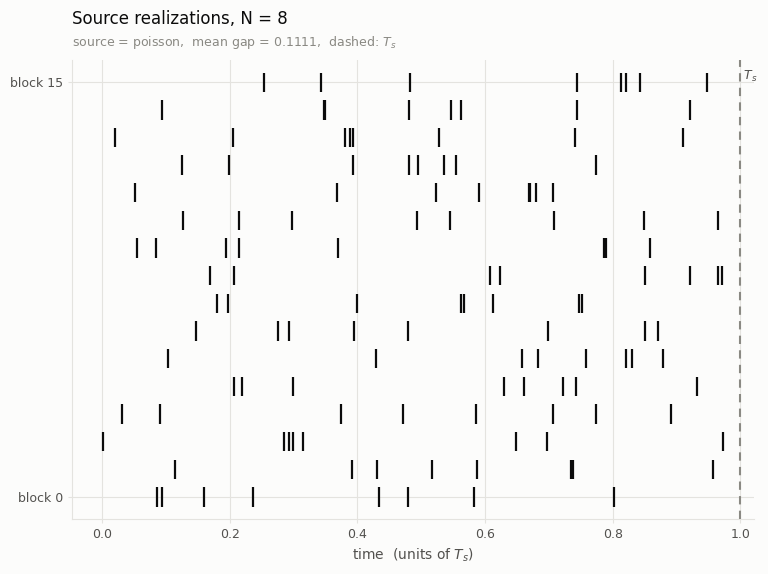

In [5]:
def fig_source_raster(cfg: Config, n_blocks: int = 16, seed: int = 3):
    """Raw realizations of the source: one block per row, one tick per event.

    n_blocks  number of stacked realizations
    seed      draw
    """
    t = sample_source(cfg, n_blocks, np.random.default_rng(seed)).numpy()
    fig, ax = plt.subplots(figsize=(7.8, 0.24 * n_blocks + 2.0), facecolor=SURFACE)
    ax.eventplot([row for row in t], colors=INK, lineoffsets=np.arange(n_blocks),
                 linelengths=0.7, linewidths=1.6, zorder=5)
    ax.axvline(cfg.Ts, color=MUTED, lw=1.5, ls=(0, (4, 3)), zorder=4)
    ax.text(cfg.Ts, n_blocks - 0.5, " $T_s$", color=INK2, fontsize=9, va="top")
    ax.set_ylim(-0.8, n_blocks - 0.2)
    ax.set_yticks([0, n_blocks - 1])
    ax.set_yticklabels(["block 0", f"block {n_blocks - 1}"])
    if cfg.source == "poisson":
        label = "source = poisson"
    elif cfg.source == "gamma":
        label = f"source = gamma, k = {cfg.gamma_k:g}"
    else:
        label = (f"source = hawkes, n = {cfg.hawkes_branching:g}, "
                 f"decay = {cfg.hawkes_decay:g} gap")
    style(ax, "time  (units of $T_s$)", "",
          f"Source realizations, N = {cfg.n_events}",
          f"{label},  mean gap = {cfg.mean_gap:.4f},  dashed: $T_s$")
    fig.tight_layout()
    return fig


fig_source_raster(CFG, n_blocks=RASTER_N_BLOCKS, seed=RASTER_SEED)
plt.show()


`hawkes`: self-exciting process with an exponential kernel,

```
lambda(t) = mu + alpha * sum_{T_i < t} exp(-beta * (t - T_i))
```

each event temporarily raises the intensity, so points arrive in bursts
followed by silences, unlike Poisson where the gaps are i.i.d. `mu`,
`alpha`, `beta` are derived from `mean_gap`, `hawkes_branching` (n = alpha/beta, the
share of the rate coming from self-excitation) and `hawkes_decay` (lifetime of
the excitation), so that the mean equilibrium rate stays `1/mean_gap` like the
other two sources. Simulated exactly via Ogata's (1981) thinning, with a
burn-in to start in the stationary regime rather than in a warm-up phase.

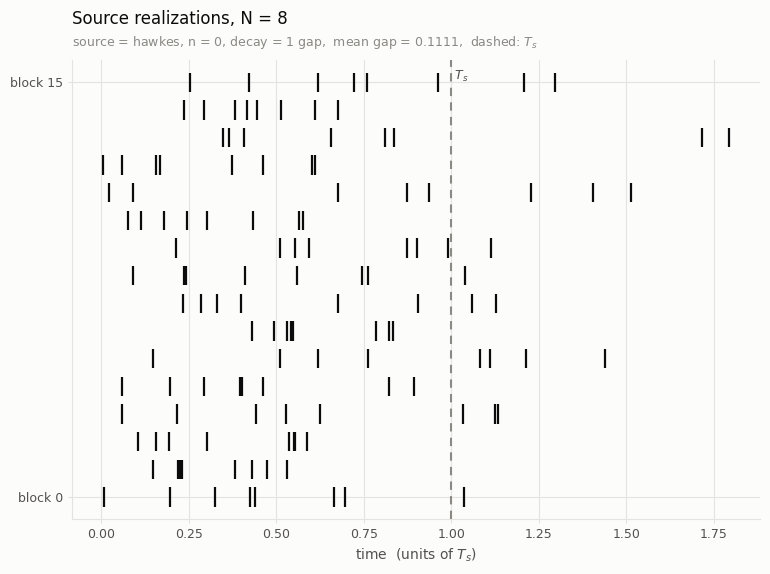

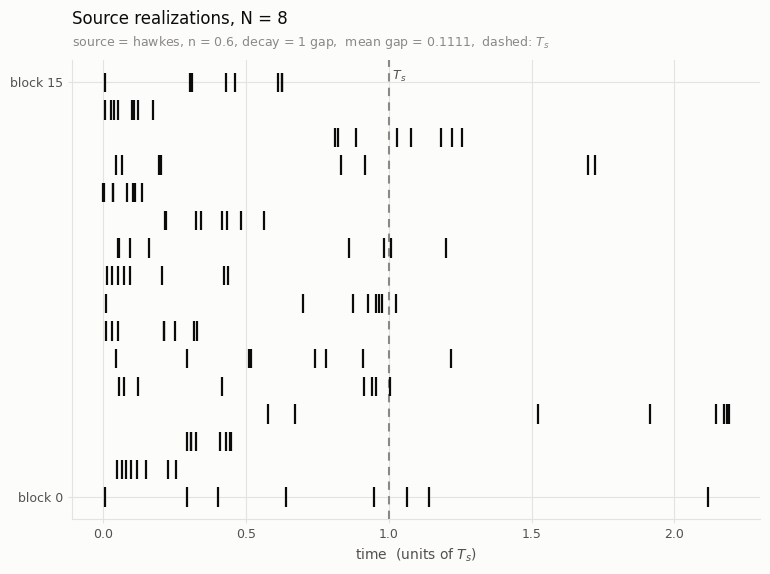

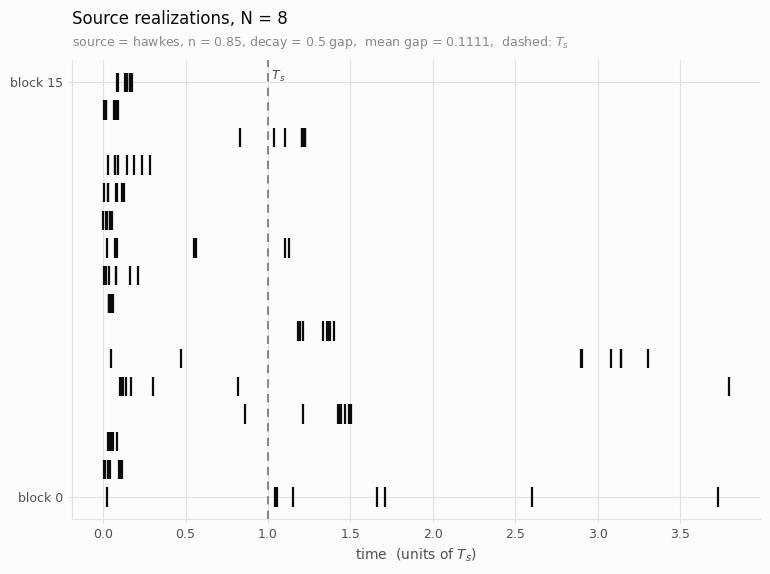

In [6]:
fig_source_raster(replace(CFG, source="hawkes", hawkes_branching=0.0),
                  n_blocks=RASTER_N_BLOCKS, seed=RASTER_SEED)
plt.show()
fig_source_raster(replace(CFG, source="hawkes", hawkes_branching=0.6),
                  n_blocks=RASTER_N_BLOCKS, seed=RASTER_SEED)
plt.show()
fig_source_raster(replace(CFG, source="hawkes", hawkes_branching=0.85, hawkes_decay=0.5),
                  n_blocks=RASTER_N_BLOCKS, seed=RASTER_SEED)
plt.show()


## Channel

`Y = sort(X + Z)`. Sorting is what makes reorderings possible: two nearby events
can be swapped by the noise, and the pairing `T_i <-> Y_i` is then wrong.
`sort_output=False` disables sorting.


In [7]:
def channel(x: torch.Tensor, sigma: float, cfg: Config,
            gen: torch.Generator | None = None):
    """(B,N) -> (B,N). Also returns the permutation applied by sorting."""
    z = torch.randn(x.shape, generator=gen, device=x.device) * sigma
    y = x + z
    if cfg.sort_output:
        y, perm = y.sort(dim=1)
    else:
        perm = torch.arange(x.shape[1], device=x.device).expand_as(x)
    return y, perm


def reorder_rates(x: torch.Tensor, perm: torch.Tensor) -> dict:
    """How much the channel shuffled the events."""
    idx = torch.arange(x.shape[1], device=x.device).expand_as(perm)
    moved = perm != idx
    return {"reorder_event_frac": float(moved.float().mean()),
            "reorder_block_frac": float(moved.any(dim=1).float().mean())}


## Systems

The encoder and the decoder read the same feature set: normalized times and
gaps. The gaps are provided explicitly because the relative geometry is
precisely the quantity at stake.

The displacement `delta = X - S` is the encoder's output, so `N_X = N_S` by
construction and no gain can come from adding events.


In [8]:
def block_features(t: torch.Tensor, cfg: Config) -> torch.Tensor:
    """(B,N) -> (B,2N): times / Ts, then gaps / mean_gap (first gap from 0)."""
    s = t / cfg.Ts
    g = torch.diff(t, dim=1, prepend=torch.zeros_like(t[:, :1])) / cfg.mean_gap
    return torch.cat([s, g], dim=1)


class MLP(nn.Module):
    """Last layer initialized to zero: the head starts at the neutral output."""

    def __init__(self, d_in, d_out, hidden, depth):
        super().__init__()
        layers, d = [], d_in
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.GELU()]
            d = hidden
        head = nn.Linear(d, d_out)
        nn.init.zeros_(head.weight)
        nn.init.zeros_(head.bias)
        self.net = nn.Sequential(*layers, head)

    def forward(self, x):
        return self.net(x)


class Encoder(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = MLP(2 * cfg.n_events, cfg.n_events, cfg.hidden, cfg.depth)

    def forward(self, t):
        cfg = self.cfg
        raw = self.net(block_features(t, cfg))
        if cfg.disp_mode == "bounded":
            delta = cfg.max_disp * cfg.mean_gap * torch.tanh(raw)
        elif cfg.disp_mode == "free":
            delta = cfg.mean_gap * raw
        else:
            raise ValueError(cfg.disp_mode)
        x = t + delta
        if cfg.window == "clamp":
            x = x.clamp(0.0, cfg.Tc)
        return x, delta


class Decoder(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = MLP(2 * cfg.n_events, cfg.n_events, cfg.hidden, cfg.depth)

    def forward(self, y):
        cfg = self.cfg
        raw = self.net(block_features(y, cfg))
        if cfg.dec_residual:
            return y + cfg.mean_gap * raw
        return cfg.Ts * torch.sigmoid(raw)


class System(nn.Module):
    """mode: "uncoded" (no parameters) | "decoder" | "jscc"."""

    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = Encoder(cfg) if mode == "jscc" else None
        self.decoder = Decoder(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, t, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        if self.encoder is None:
            x, delta = t, torch.zeros_like(t)
        else:
            x, delta = self.encoder(t)
        y, perm = channel(x, sigma, self.cfg, gen)
        s_hat = y if self.decoder is None else self.decoder(y)
        return {"s_hat": s_hat, "x": x, "y": y, "delta": delta, "perm": perm}

    @property
    def n_params(self) -> int:
        return sum(p.numel() for p in self.parameters())


## Training and measurements

The loss is the chosen distortion, with no auxiliary term. `measure` returns all three
distortions regardless of which one was used for training, plus measurements of the
learned code: displacement magnitude, channel reorderings, minimum gap, overflows.


In [9]:
def distortion_terms(t: torch.Tensor, s_hat: torch.Tensor, cfg: Config) -> dict:
    e = s_hat - t
    return {"mse": (e ** 2).mean(), "mae": e.abs().mean(),
            "huber": F.huber_loss(s_hat, t, delta=cfg.huber_delta)}


def train_system(cfg: Config, mode: str, verbose: bool = False):
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed + 1)
    model = System(cfg, mode).to(DEVICE)
    history = []
    if model.n_params == 0:
        return model, history

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                total_steps=cfg.steps, pct_start=0.1)
    t0 = time.time()
    for step in range(1, cfg.steps + 1):
        t = sample_source(cfg, cfg.batch, rng)
        out = model(t, gen=gen)
        loss = distortion_terms(t, out["s_hat"], cfg)[cfg.distortion]
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()
        if step % max(1, cfg.steps // 10) == 0 or step == cfg.steps:
            history.append({"step": step, "loss": float(loss.detach())})
            if verbose:
                print(f"  {mode:8s} step {step:6d}  loss {float(loss.detach()):.3e}"
                      f"  {time.time() - t0:.0f}s", flush=True)
    return model, history


@torch.no_grad()
def measure(model: System, cfg: Config, sigma=None, seed: int = 99991) -> dict:
    sigma = cfg.sigma_J if sigma is None else sigma
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    model.eval()
    acc, reps = {}, cfg.eval_reps
    for _ in range(reps):
        t = sample_source(cfg, cfg.eval_batch, rng)
        o = model(t, sigma=sigma, gen=gen)
        d = {k: float(v) for k, v in distortion_terms(t, o["s_hat"], cfg).items()}
        gx = torch.diff(o["x"].sort(dim=1).values, dim=1)
        gs = torch.diff(t, dim=1)
        x_raw = t + o["delta"]
        row = {**{f"d_{k}": v for k, v in d.items()},
               **reorder_rates(o["x"], o["perm"]),
               "mean_abs_delta_gaps": float(o["delta"].abs().mean() / cfg.mean_gap),
               "min_gap_X_gaps": float(gx.min(dim=1).values.mean() / cfg.mean_gap),
               "min_gap_S_gaps": float(gs.min(dim=1).values.mean() / cfg.mean_gap),
               "frac_X_out_preclamp": float(((x_raw < 0) | (x_raw > cfg.Tc)).float().mean()),
               "frac_X_outside": float(((o["x"] < 0) | (o["x"] > cfg.Tc)).float().mean())}
        for k, v in row.items():
            acc[k] = acc.get(k, 0.0) + v / reps
    model.train()
    return acc | {"sigma_J": sigma, "sigma_over_gap": sigma / cfg.mean_gap,
                  "mode": model.mode, "n_params": model.n_params}


## Step 1 — Poisson source

Sweep of `sigma_J` in units of mean gap, the three systems at the same rate and the
same number of events. `uncoded` has no parameters and is not trained.


In [10]:
def run_sweep(base: Config, sigma_grid=SIGMA_GRID, modes=MODES, verbose=True):
    """One model per (sigma, mode). Returns the list of measurements and the models."""
    rows, models = [], {}
    for sg in sigma_grid:
        cfg = replace(base, sigma_J=sg * base.mean_gap)
        for mode in modes:
            t0 = time.time()
            model, hist = train_system(cfg, mode)
            m = measure(model, cfg)
            m["train_seconds"] = time.time() - t0
            m["loss_end"] = hist[-1]["loss"] if hist else float("nan")
            rows.append(m)
            models[(sg, mode)] = (model, cfg, hist)
            if verbose:
                print(f"sigma/gap {sg:4.2f}  {mode:8s}  d_mse {m['d_mse']:.3e}"
                      f"  reorder/event {m['reorder_event_frac']:.4f}"
                      f"  |delta| {m['mean_abs_delta_gaps']:.3f} gaps"
                      f"  ({m['train_seconds']:.0f}s)", flush=True)
    return rows, models


STEP1_ROWS, STEP1_MODELS = run_sweep(CFG)


sigma/gap 0.05  uncoded   d_mse 3.004e-05  reorder/event 0.0428  |delta| 0.000 gaps  (0s)


sigma/gap 0.05  decoder   d_mse 2.965e-05  reorder/event 0.0428  |delta| 0.000 gaps  (5s)


sigma/gap 0.05  jscc      d_mse 2.840e-05  reorder/event 0.0791  |delta| 0.034 gaps  (8s)


sigma/gap 0.10  uncoded   d_mse 1.168e-04  reorder/event 0.0826  |delta| 0.000 gaps  (0s)


sigma/gap 0.10  decoder   d_mse 1.119e-04  reorder/event 0.0826  |delta| 0.000 gaps  (4s)


...

sigma/gap 0.40  decoder   d_mse 1.336e-03  reorder/event 0.2804  |delta| 0.000 gaps  (4s)


sigma/gap 0.40  jscc      d_mse 9.423e-04  reorder/event 0.4535  |delta| 0.412 gaps  (8s)


sigma/gap 0.80  uncoded   d_mse 5.399e-03  reorder/event 0.4558  |delta| 0.000 gaps  (0s)


sigma/gap 0.80  decoder   d_mse 3.742e-03  reorder/event 0.4558  |delta| 0.000 gaps  (4s)


sigma/gap 0.80  jscc      d_mse 2.427e-03  reorder/event 0.5704  |delta| 0.641 gaps  (8s)


In [11]:
def show_table(rows, cols=None, title=""):
    cols = cols or ["sigma_over_gap", "mode", "d_mse", "d_mae",
                    "reorder_event_frac", "mean_abs_delta_gaps",
                    "min_gap_X_gaps", "frac_X_out_preclamp", "n_params"]
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells.append(str(v).rjust(w[c]))
        print(" | ".join(cells))


show_table(STEP1_ROWS, title=f"Step 1 — Poisson, N={CFG.n_events}")
print("\nsigma_J^2 for reference, in units of Ts^2:")
for sg in SIGMA_GRID:
    s = sg * CFG.mean_gap
    print(f"  sigma/gap {sg:4.2f}  sigma_J {s:.5f}  sigma_J^2 {s ** 2:.4e}")


Step 1 — Poisson, N=8
sigma_over_gap |        mode |       d_mse |       d_mae | reorder_event_frac | mean_abs_delta_gaps | min_gap_X_gaps | frac_X_out_preclamp |    n_params
---------------+-------------+-------------+-------------+--------------------+---------------------+----------------+---------------------+------------
        0.0500 |     uncoded |  3.0040e-05 |      0.0044 |             0.0428 |              0.0000 |         0.1429 |              0.0000 |           0
        0.0500 |     decoder |  2.9651e-05 |      0.0043 |             0.0428 |              0.0000 |         0.1429 |              0.0000 |       36232
        0.0500 |        jscc |  2.8403e-05 |      0.0042 |             0.0791 |              0.0336 |         0.1181 |              0.0139 |       72464
        0.1000 |     uncoded |  1.1684e-04 |      0.0086 |             0.0826 |              0.0000 |         0.1429 |              0.0000 |           0
        0.1000 |     decoder |  1.1190e-04 |      0.0084 |  

### Step 1 figures

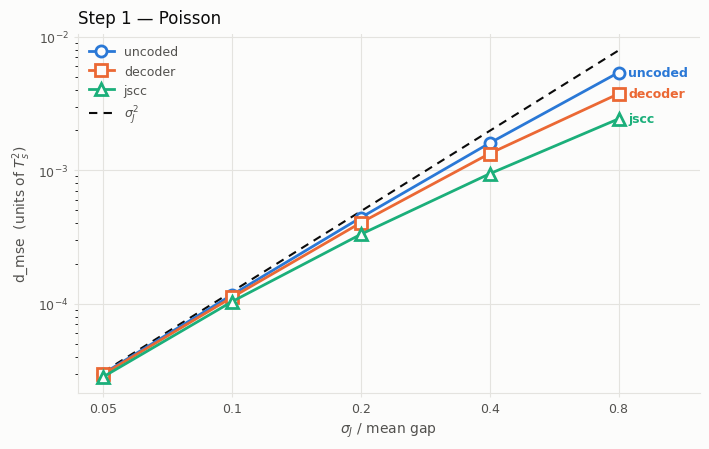

In [12]:
def fig_distortion(rows, metric="d_mse", title="Step 1 — Poisson"):
    fig, ax = plt.subplots(figsize=(7.2, 4.6), facecolor=SURFACE)
    for mode in MODES:
        pts = sorted([r for r in rows if r["mode"] == mode],
                     key=lambda r: r["sigma_over_gap"])
        if not pts:
            continue
        colour, marker = MODE_STYLE[mode]
        xs = [r["sigma_over_gap"] for r in pts]
        ys = [r[metric] for r in pts]
        ax.plot(xs, ys, color=colour, lw=2.0, marker=marker, ms=8, mew=2.0,
                mfc=SURFACE, mec=colour, zorder=5, label=mode)
        ax.annotate(mode, (xs[-1], ys[-1]), textcoords="offset points",
                    xytext=(7, 0), color=colour, fontsize=9, fontweight="bold",
                    va="center")
    sg = np.array(sorted({r["sigma_over_gap"] for r in rows}))
    mean_gap = rows[0]["sigma_J"] / rows[0]["sigma_over_gap"]
    if metric == "d_mse":
        ax.plot(sg, (sg * mean_gap) ** 2, color=INK, lw=1.5, ls=(0, (4, 3)),
                zorder=4, label="$\\sigma_J^2$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(list(sg))
    ax.set_xticklabels([f"{v:g}" for v in sg], fontsize=9)
    ax.set_xticks([], minor=True)
    ax.set_xlim(right=sg[-1] * 1.55)
    unit = "$T_s^2$" if metric == "d_mse" else "$T_s$"
    style(ax, "$\\sigma_J$ / mean gap", f"{metric}  (units of {unit})", title)
    legend(ax)
    fig.tight_layout()
    return fig


fig_distortion(STEP1_ROWS)
plt.show()


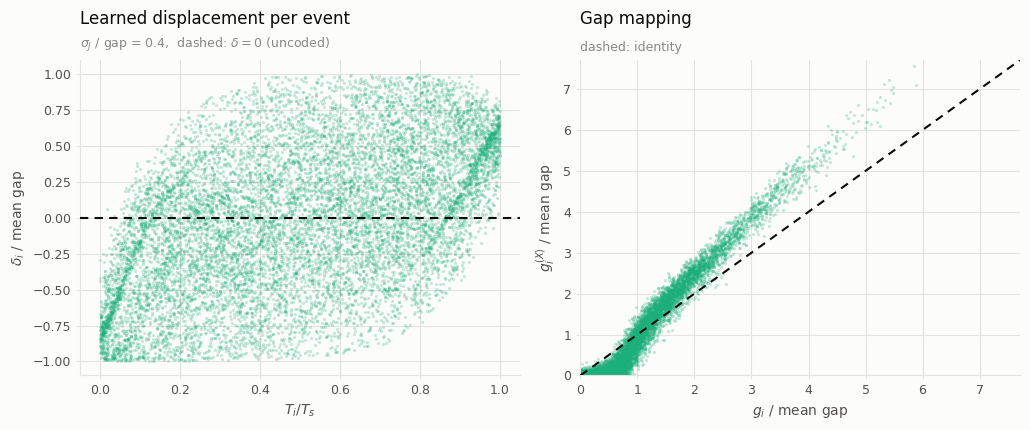

In [13]:
def fig_code(models, sg, n_blocks=1500, seed=4242):
    """The learned code at a given sigma: displacement per event, and gaps."""
    model, cfg, _ = models[(sg, "jscc")]
    rng = np.random.default_rng(seed)
    with torch.no_grad():
        t = sample_source(cfg, n_blocks, rng)
        x, delta = model.encoder(t)
    t_np = (t.numpy() / cfg.Ts).ravel()
    d_np = (delta.numpy() / cfg.mean_gap).ravel()
    gs = torch.diff(t, dim=1).numpy().ravel() / cfg.mean_gap
    gx = torch.diff(x.sort(dim=1).values, dim=1).numpy().ravel() / cfg.mean_gap

    fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4), facecolor=SURFACE)
    axes[0].scatter(t_np, d_np, s=5, color=C_JSCC, alpha=0.25, lw=0)
    axes[0].axhline(0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    style(axes[0], "$T_i / T_s$", "$\\delta_i$ / mean gap",
          "Learned displacement per event",
          f"$\\sigma_J$ / gap = {sg:g},  dashed: $\\delta = 0$ (uncoded)")

    lim = max(gs.max(), gx.max()) * 1.02
    axes[1].scatter(gs, gx, s=5, color=C_JSCC, alpha=0.25, lw=0)
    axes[1].plot([0, lim], [0, lim], color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[1].set_xlim(0, lim)
    axes[1].set_ylim(0, lim)
    style(axes[1], "$g_i$ / mean gap", "$g^{(X)}_i$ / mean gap",
          "Gap mapping", "dashed: identity")
    fig.tight_layout()
    return fig


fig_code(STEP1_MODELS, REALISATION_SIGMA, n_blocks=CODE_N_BLOCKS, seed=CODE_SEED)
plt.show()


### Encoder convergence to identity, across the source's randomness

For each sigma in the grid, we draw `n_blocks` *independent* realizations of the
Poisson source (so the process's randomness, not the training's randomness) and look
at the empirical CDF of `|delta_i| / mean_gap` over all events of all blocks. An
encoder that had converged to identity would have `delta = 0` everywhere, hence a
vertical step at 0.


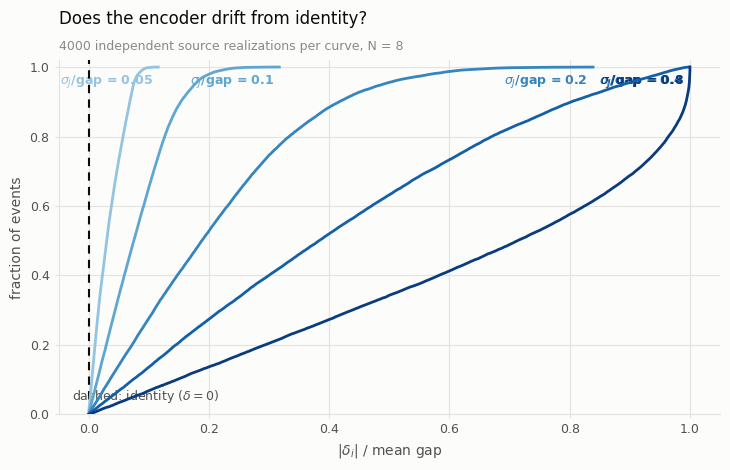

In [14]:
def fig_identity_ecdf(models, sigma_grid=SIGMA_GRID, n_blocks=4000, seed=555):
    fig, ax = plt.subplots(figsize=(7.4, 4.8), facecolor=SURFACE)
    blues = plt.get_cmap("Blues")(np.linspace(0.4, 0.95, len(sigma_grid)))
    for colour, sg in zip(blues, sigma_grid):
        model, cfg, _ = models[(sg, "jscc")]
        rng = np.random.default_rng(seed)
        with torch.no_grad():
            t = sample_source(cfg, n_blocks, rng)
            _, delta = model.encoder(t)
        d = np.sort(np.abs(delta.numpy().ravel()) / cfg.mean_gap)
        y = np.arange(1, len(d) + 1) / len(d)
        ax.plot(d, y, color=colour, lw=2.0, zorder=5)
        ax.annotate(f"$\\sigma_J$/gap = {sg:g}", (d[-1], y[-1]),
                    textcoords="offset points", xytext=(-4, -4), color=colour,
                    fontsize=9, fontweight="bold", ha="right", va="top")
    ax.axvline(0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    ax.text(0.02, 0.04, "dashed: identity ($\\delta = 0$)", transform=ax.transAxes,
            color=INK2, fontsize=9)
    ax.set_ylim(0, 1.02)
    style(ax, "$|\\delta_i|$ / mean gap", "fraction of events",
          "Does the encoder drift from identity?",
          f"{n_blocks} independent source realizations per curve, "
          f"N = {CFG.n_events}")
    fig.tight_layout()
    return fig


fig_identity_ecdf(STEP1_MODELS, sigma_grid=SIGMA_GRID,
                  n_blocks=IDENTITY_N_BLOCKS, seed=IDENTITY_SEED)
plt.show()


### Step 1c — does the pipeline converge to identity during training, at high intensity?

Hypothesis to test (a remark from the PDF for step 1): the Poisson source is the most
"random" case considered, so the learned encoder might simply converge to
uncoded transmission.

`HIGH_N_CFG` takes `CFG` with `n_events` multiplied by 8 (high intensity: 8 times
more events over the same duration `Ts`, hence a mean gap 8 times smaller), at the same
`sigma_over_gap` as one point of the step-1 grid. `train_track_identity` trains
`jscc` while evaluating, at regular intervals, on a *fixed* evaluation batch (same draw
at every checkpoint), the distortion and the mean deviation from identity `|delta_i|/mean_gap`.


In [15]:
def train_track_identity(cfg: Config, eval_every: int = 100, eval_batch: int = 4000,
                          eval_seed: int = 777, verbose: bool = False):
    """Trains jscc, logs distortion and deviation-from-identity on a fixed batch."""
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed + 1)
    model = System(cfg, "jscc").to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                total_steps=cfg.steps, pct_start=0.1)

    t_eval = sample_source(cfg, eval_batch, np.random.default_rng(eval_seed))

    traj = []
    t0 = time.time()
    for step in range(1, cfg.steps + 1):
        t = sample_source(cfg, cfg.batch, rng)
        out = model(t, gen=gen)
        loss = distortion_terms(t, out["s_hat"], cfg)[cfg.distortion]
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()
        if step == 1 or step % eval_every == 0 or step == cfg.steps:
            model.eval()
            with torch.no_grad():
                eval_gen = torch.Generator(device=DEVICE).manual_seed(eval_seed)
                o = model(t_eval, gen=eval_gen)
                d_mse = float(((o["s_hat"] - t_eval) ** 2).mean())
                delta_mag = float(o["delta"].abs().mean() / cfg.mean_gap)
            model.train()
            traj.append({"step": step, "d_mse": d_mse, "mean_abs_delta_gaps": delta_mag})
            if verbose:
                print(f"  step {step:6d}  d_mse {d_mse:.3e}  |delta| {delta_mag:.4f} gaps"
                      f"  {time.time() - t0:.0f}s", flush=True)
    return model, traj


HIGH_N_CFG = replace(CFG, n_events=CFG.n_events * HIGH_N_MULTIPLIER, steps=HIGH_N_STEPS)
HIGH_N_CFG = replace(HIGH_N_CFG, sigma_J=HIGH_N_SIGMA_OVER_GAP * HIGH_N_CFG.mean_gap)
print(HIGH_N_CFG)
print(f"mean_gap = {HIGH_N_CFG.mean_gap:.5f}   "
      f"sigma_over_gap = {HIGH_N_CFG.sigma_J / HIGH_N_CFG.mean_gap:.3f}")

UNCODED_REF = measure(System(HIGH_N_CFG, "uncoded"), HIGH_N_CFG)["d_mse"]
print(f"uncoded reference (no learning): d_mse = {UNCODED_REF:.3e}")

TRACK_MODEL, TRACK_TRAJ = train_track_identity(HIGH_N_CFG, eval_every=HIGH_N_EVAL_EVERY,
                                               verbose=True)


Config(n_events=64, Ts=1.0, source='poisson', gamma_k=1.0, hawkes_branching=0.5, hawkes_decay=1.0, sigma_J=0.0030769230769230774, sort_output=True, disp_mode='bounded', max_disp=1.0, window='clamp', dec_residual=True, hidden=128, depth=3, distortion='mse', huber_delta=0.02, steps=6000, batch=512, lr=0.003, seed=0, eval_batch=20000, eval_reps=2)
mean_gap = 0.01538   sigma_over_gap = 0.200
uncoded reference (no learning): d_mse = 8.234e-06
  step      1  d_mse 8.233e-06  |delta| 0.0002 gaps  0s


  step    100  d_mse 8.228e-06  |delta| 0.0013 gaps  0s


  step    200  d_mse 8.219e-06  |delta| 0.0027 gaps  1s


  step    300  d_mse 8.192e-06  |delta| 0.0046 gaps  1s


  step    400  d_mse 8.100e-06  |delta| 0.0125 gaps  1s


...

  step   5600  d_mse 7.185e-06  |delta| 0.1148 gaps  18s


  step   5700  d_mse 7.183e-06  |delta| 0.1152 gaps  18s


  step   5800  d_mse 7.182e-06  |delta| 0.1152 gaps  19s


  step   5900  d_mse 7.181e-06  |delta| 0.1153 gaps  19s


  step   6000  d_mse 7.181e-06  |delta| 0.1153 gaps  19s


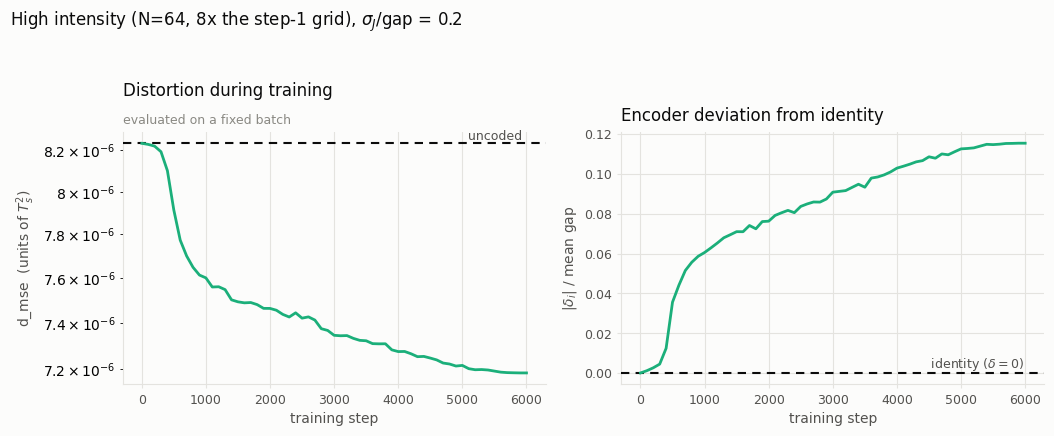

In [16]:
def fig_identity_over_training(traj, uncoded_ref, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4), facecolor=SURFACE)
    steps = [r["step"] for r in traj]

    d = [r["d_mse"] for r in traj]
    axes[0].plot(steps, d, color=C_JSCC, lw=2.0, zorder=5, label="jscc")
    axes[0].axhline(uncoded_ref, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[0].text(steps[-1], uncoded_ref, " uncoded ", color=INK2, fontsize=9,
                 va="bottom", ha="right")
    axes[0].set_yscale("log")
    style(axes[0], "training step", "d_mse  (units of $T_s^2$)",
          "Distortion during training", "evaluated on a fixed batch")

    dl = [r["mean_abs_delta_gaps"] for r in traj]
    axes[1].plot(steps, dl, color=C_JSCC, lw=2.0, zorder=5)
    axes[1].axhline(0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[1].text(steps[-1], 0, " identity ($\\delta=0$) ", color=INK2,
                 fontsize=9, va="bottom", ha="right")
    style(axes[1], "training step", "$|\\delta_i|$ / mean gap",
          "Encoder deviation from identity")

    fig.suptitle(title, color=INK, fontsize=12, x=0.01, ha="left")
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig


fig_identity_over_training(
    TRACK_TRAJ, UNCODED_REF,
    title=(f"High intensity (N={HIGH_N_CFG.n_events}, 8x the step-1 grid), "
           f"$\\sigma_J$/gap = {HIGH_N_CFG.sigma_J / HIGH_N_CFG.mean_gap:g}"))
plt.show()


## Step 1b — one realization followed through the chain

Four rows, one per stage: the source, the codeword, the channel output, the
reconstruction. Segments connect each event to its image, so a crossing
between the `X` row and the `Y` row is a reordering produced by the channel's sorting.

Figure parameters: `sg` the sigma taken from the grid, `mode` the system, `block`
the drawn block's index, `seed` the draw.


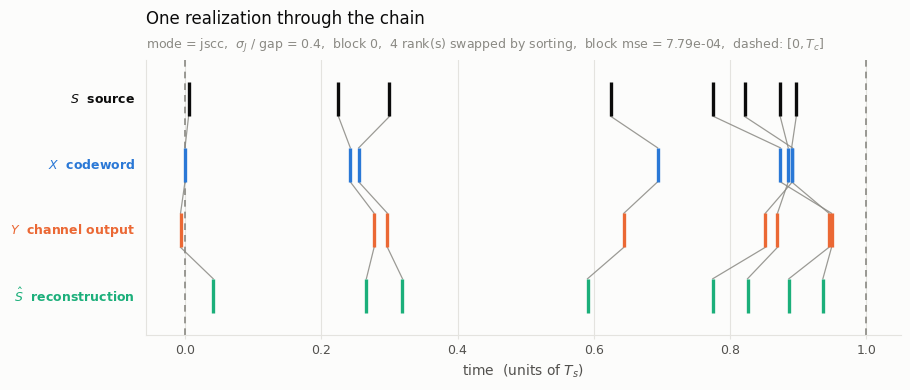

In [17]:
def fig_realisation(models, sg, mode="jscc", block=0, seed=7):
    model, cfg, _ = models[(sg, mode)]
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        t = sample_source(cfg, block + 1, rng)
        o = model(t, gen=gen)
    S = t[block].numpy()
    X = o["x"][block].numpy()
    Y = o["y"][block].numpy()
    H = o["s_hat"][block].numpy()
    perm = o["perm"][block].numpy()

    rows = [("$S$  source", S, INK),
            ("$X$  codeword", X, C_UNCODED),
            ("$Y$  channel output", Y, C_DECODER),
            ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")

    # correspondences: S_i -> X_i, then X_{perm[j]} -> Y_j, then Y_j -> S_hat_j
    for i in range(len(S)):
        ax.plot([S[i], X[i]], [3 - 0.26, 2 + 0.26], color=MUTED, lw=0.9,
                alpha=0.85, zorder=3)
    for j in range(len(Y)):
        ax.plot([X[perm[j]], Y[j]], [2 - 0.26, 1 + 0.26], color=MUTED, lw=0.9,
                alpha=0.85, zorder=3)
        ax.plot([Y[j], H[j]], [1 - 0.26, 0 + 0.26], color=MUTED, lw=0.9,
                alpha=0.85, zorder=3)

    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    n_swap = int((perm != np.arange(len(X))).sum())
    err = float(((H - S) ** 2).mean())
    sub = (f"mode = {mode},  $\\sigma_J$ / gap = {sg:g},  block {block},  "
           f"{n_swap} rank(s) swapped by sorting,  block mse = {err:.2e},  "
           "dashed: $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6)
    ax.set_yticks([])
    style(ax, "time  (units of $T_s$)", "",
          "One realization through the chain", sub)
    fig.tight_layout()
    return fig


fig_realisation(STEP1_MODELS, REALISATION_SIGMA, mode="jscc",
                block=REALISATION_BLOCK, seed=REALISATION_SEED)
plt.show()


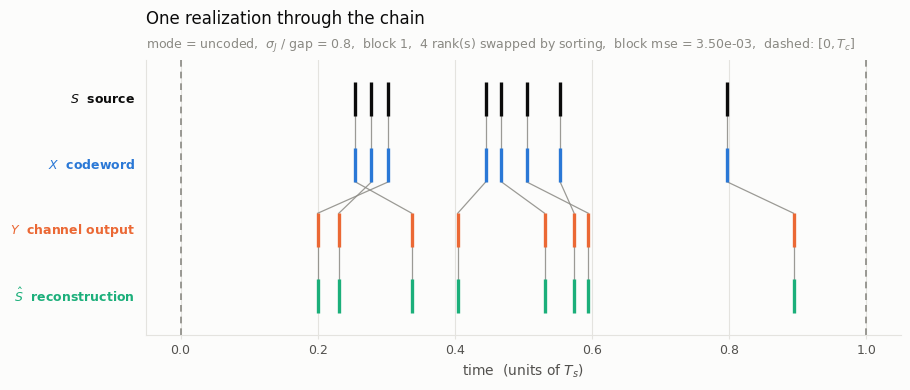

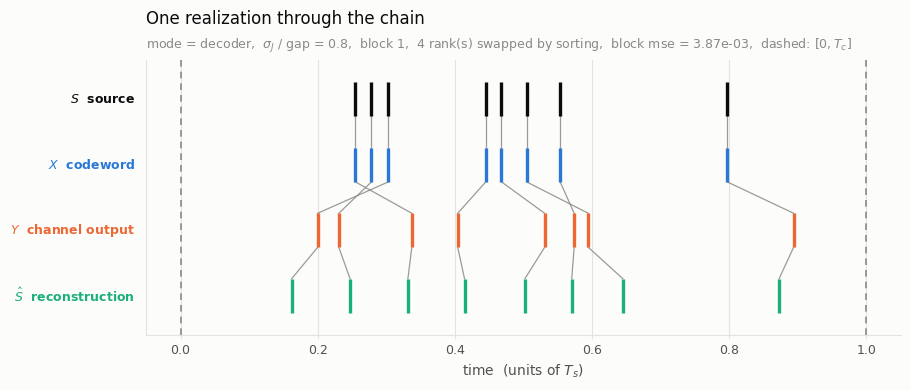

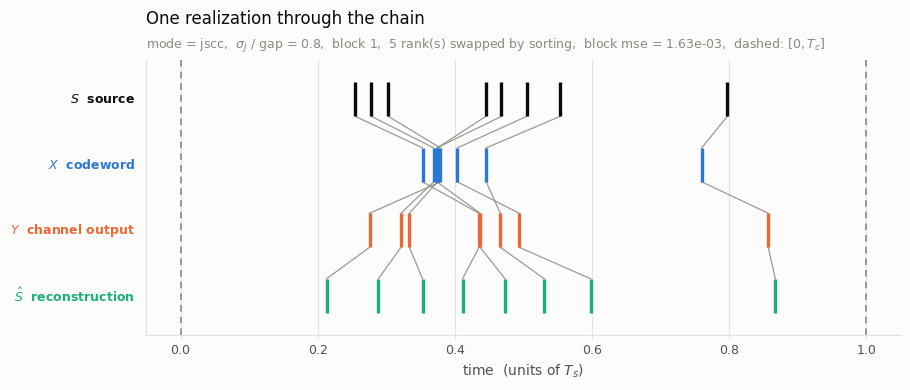

In [18]:
# the three systems on the same block, at the grid's strongest jitter
for m in MODES:
    fig_realisation(STEP1_MODELS, CONTROL_SIGMA, mode=m, block=CONTROL_BLOCK)
    plt.show()
